# Denoising Autoencoder for Cassini CDA Mass Spectra

This notebook implements a **Denoising Autoencoder (DAE)** to analyze mass spectra from the Cassini Cosmic Dust Analyzer (CDA).

### Why Denoising Autoencoder?
Denoising autoencoders are trained to reconstruct **clean signals from corrupted inputs**, forcing the model to learn robust, noise-invariant features. This has several advantages:

1. **Noise Robustness**: Learns features that are resistant to random noise and corruption
2. **Feature Learning**: Forces the network to capture essential spectral patterns rather than memorizing input
3. **Regularization**: Noise injection acts as a strong regularizer, preventing overfitting
4. **Better Generalization**: Produces more robust latent representations that generalize better

### Architecture Highlights:
- **Noise Injection**: Adds Gaussian noise to input spectra during training
- **CNN Encoder**: Extracts robust features from noisy input spectra
- **Bottleneck**: 128-dimensional latent space for compact representation
- **CNN Decoder**: Reconstructs clean spectra from noisy latent features
- **Reconstruction Loss**: MSE between clean output and original clean input

### Pipeline Steps:
1. **Data Loading**: Load Parquet files containing the spectra
2. **Preprocessing**: Savitzky-Golay filtering → log transformation → normalization
3. **Model Architecture**: Denoising Autoencoder with 128-dim latent space
4. **Training**: Add noise to inputs, minimize reconstruction error to clean targets
5. **Evaluation**: Ground truth metrics (Silhouette, Linear Probe, Reconstruction Error)

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN, KMeans
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Configuration
Input_Length = 1000  # Number of bins to resample spectra to
Batch_Size = 128
Learning_Rate = 1e-3
Epochs = 20
Latent_Dim = 128  # Dimension of latent bottleneck
Noise_Factor = 0.3  # Strength of Gaussian noise added to inputs (0.0-1.0)

# NEW: Advanced training configuration for chemical signal prioritization
Intensity_Weight_Power = 2.0  # Power for intensity weighting (1.0 = linear, 2.0 = squared)
L1_Lambda = 1e-4  # L1 penalty weight for latent sparsity (0.0001)
Use_Class_Balanced_Sampling = True  # Enable class-balanced sampling

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### 1. Data Loading
We load the data from a Parquet file. This efficient columnar format allows us to handle large datasets of spectra quickly. We also filter or crop the data to ensure we are only training on valid signals.

### 1.1 Class Analysis
Before training, it is crucial to understand the class imbalance. Real-world space data is dominated by "Noise" or empty impacts. Knowing the distribution helps us interpret why the model might cluster certain things together (e.g., if 90% of data is noise, the model will prioritize learning the shape of noise).

In [2]:
# 1. Load Data
# Adjust the filename as needed based on which file you want to train on
file_path = 'cda_qm_spectra_pre2008277_train_lvl2.parquet'

try:
    df = pd.read_parquet(file_path)
    print(f"Loaded data shape: {df.shape}")
    print(df.head())
    
    # Extract spectral data
    # Based on the output, the column is named 'spectrum'
    if 'spectrum' in df.columns:
        print("Found 'spectrum' column.")
        # Ensure it's a stack of numpy arrays
        spectra_raw = np.stack(df['spectrum'].values)
    else:
        raise ValueError(f"Column 'spectrum' not found. Available columns: {df.columns}")

except Exception as e:
    print(f"Error loading data: {e}")
    raise e

Loaded data shape: (19820, 6)
           sclk   f_desc  event_id  \
0  1.477582e+09  6405615      4035   
1  1.477619e+09  6405615      6860   
2  1.477626e+09  6405615     10363   
3  1.477630e+09  6405615     12290   
4  1.477666e+09  6405615     16489   

                                            spectrum       qi_ampl  class  
0  [-6.986339e-07, 0.0, 0.0, -8.7329244e-07, 5.23...  5.004700e-14  Noise  
1  [-1.7465848e-07, -8.7329244e-07, -1.7465848e-0...  4.182420e-14  3-Car  
2  [-1.7465848e-07, -1.7465848e-07, -1.7465848e-0...  1.700580e-14  3-Car  
3  [-3.4931696e-07, -3.4931696e-07, -3.4931696e-0...  1.312510e-14  3-KNa  
4  [-6.986339e-07, 0.0, -3.4931696e-07, -5.239755...  4.949150e-12  Noise  
Found 'spectrum' column.


Class distribution:
class
Noise    12077
1         4491
2         1015
3          909
?          553
4          263
5          186
3-Car       89
3-Cl        47
3-OH        47
3-KNa       41
5-Na        41
3-P         34
3-K         22
2-X          3
X            2
Name: count, dtype: int64

Total number of classes: 16


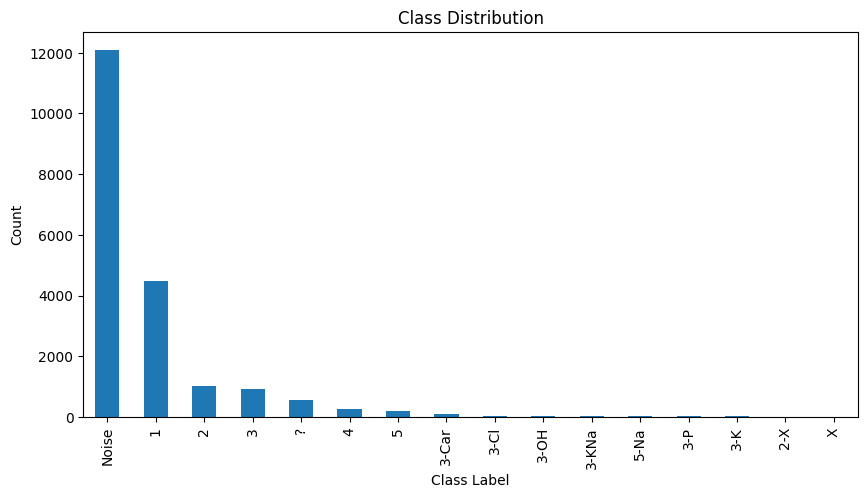

In [3]:
# 1.1 Analyze Classes
if 'class' in df.columns:
    print("Class distribution:")
    class_counts = df['class'].value_counts()
    print(class_counts)
    print(f"\nTotal number of classes: {len(class_counts)}")
    
    # Optional: Plot class distribution
    plt.figure(figsize=(10, 5))
    class_counts.plot(kind='bar')
    plt.title("Class Distribution")
    plt.ylabel("Count")
    plt.xlabel("Class Label")
    plt.show()
else:
    print("Column 'class' not found in dataframe.")

### 2. Preprocessing
We define a function to normalize and reshape the spectra.
*   **Target Length:** 1000 bins. This reduces the input dimensionality while preserving the resolution needed to distinguish mass lines.
*   **Denoising:** Apply Savitzky-Golay filter to smooth out high-frequency noise while preserving peak shapes. This is crucial for mass spectra where sharp peaks contain the chemical information.
*   **Log1p:** $\log(1+x)$ is used to squash the counts. Without this, a single giant peak (e.g., Amplitude 10,000) would render a small but chemically significant peak (Amplitude 10) invisible to the network (it would look like 0.001 after normalization).
*   **Normalization:** Scale to 0-1 range for stable neural network training.

Preprocessing data...
Processed Data Shape: (19820, 1000)

Class Distribution:
  Chemical samples: 7743
  Noise samples: 12077

✓ Class-balanced sampling enabled
  Chemical weight: 0.0001
  Noise weight: 0.0001
DataLoader created.
PREPROCESSING VISUALIZATION
  Key transformations:
    1. Crop/Pad → Fixed 1000-bin length
    2. Savitzky-Golay → Noise reduction while preserving peaks
    3. Log1p → Compress dynamic range (handle large/small peaks)
    4. Normalization → Scale to [0,1] for stable training

Processed Data Shape: (19820, 1000)

Class Distribution:
  Chemical samples: 7743
  Noise samples: 12077

✓ Class-balanced sampling enabled
  Chemical weight: 0.0001
  Noise weight: 0.0001
DataLoader created.
PREPROCESSING VISUALIZATION
  Key transformations:
    1. Crop/Pad → Fixed 1000-bin length
    2. Savitzky-Golay → Noise reduction while preserving peaks
    3. Log1p → Compress dynamic range (handle large/small peaks)
    4. Normalization → Scale to [0,1] for stable training



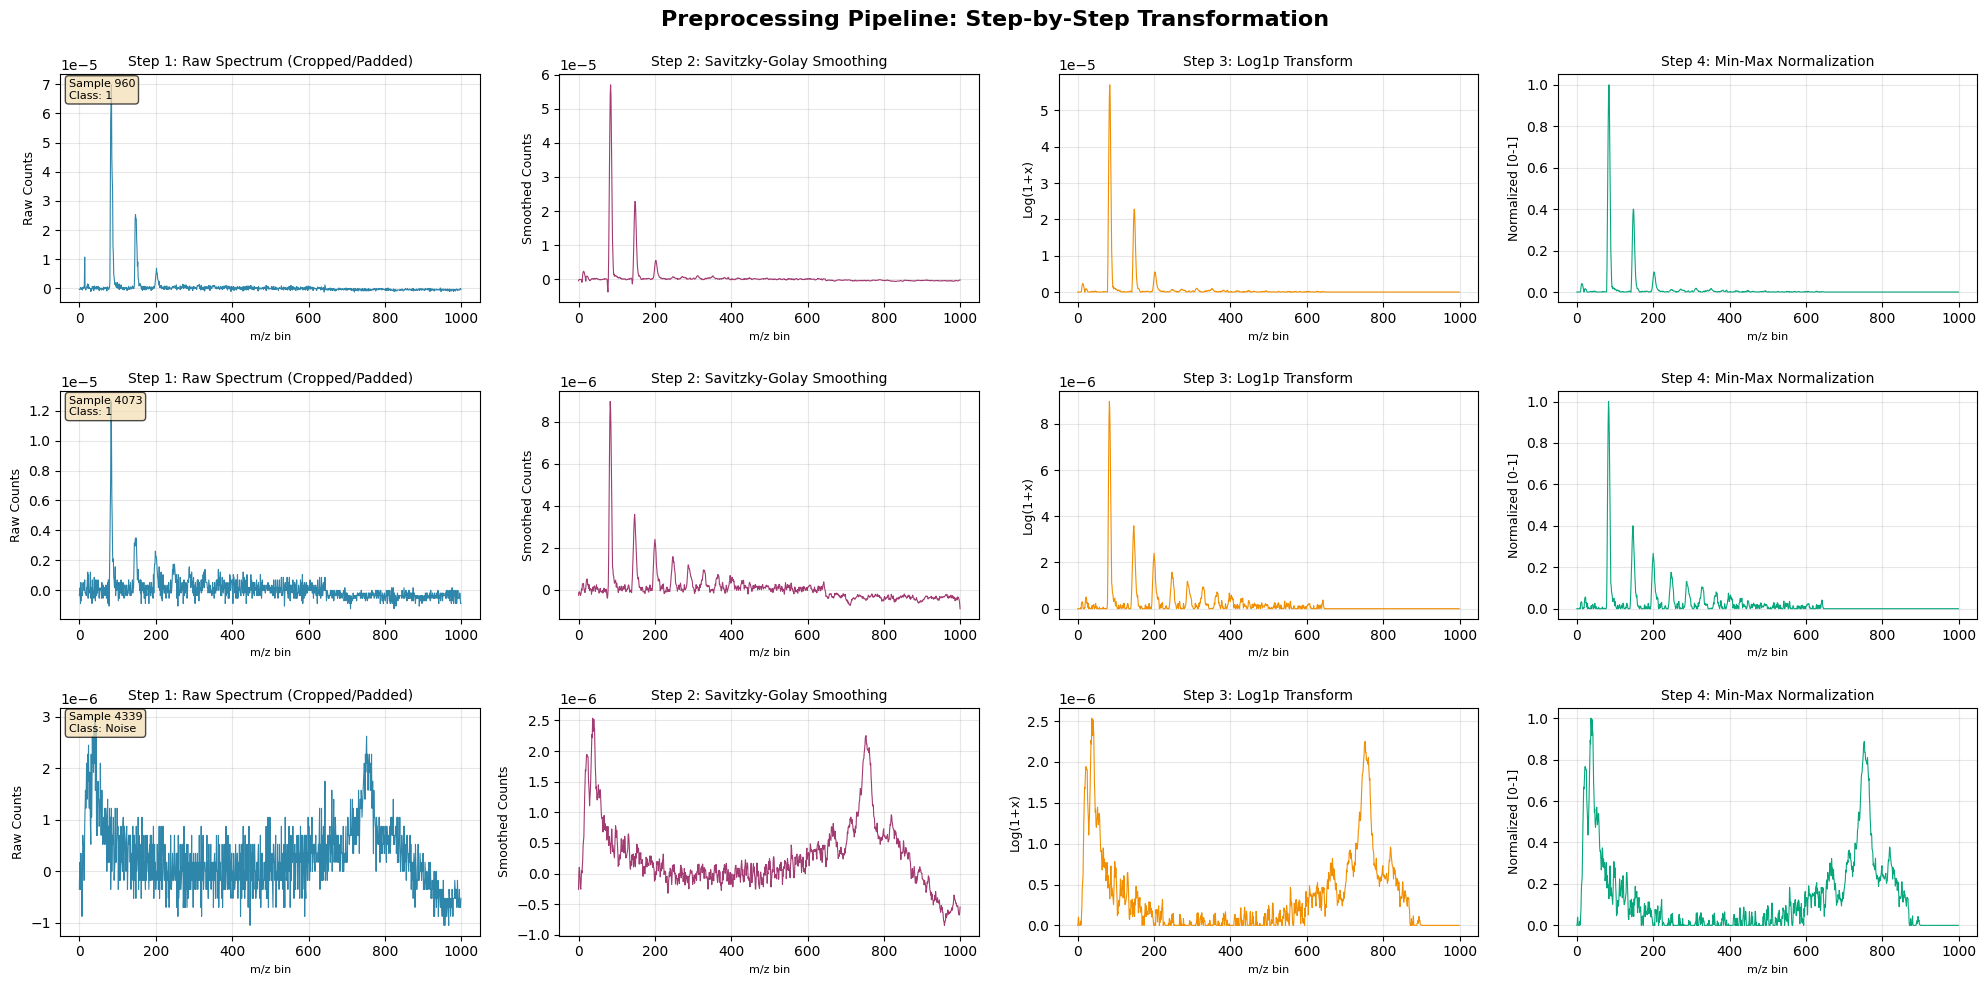


✓ Preprocessing visualization complete


In [4]:
# 2. Preprocessing Function
def preprocess_spectra(spectra, target_length=1000):
    processed = []
    
    for spec in spectra:
        # A. Handling varying lengths (if raw data is list of arrays)
        # Resize or pad/crop to target_length
        if len(spec) >= target_length:
            s = spec[:target_length]
        else:
            s = np.pad(spec, (0, target_length - len(spec)), 'constant')
        
        # B. Denoising with Savitzky-Golay filter
        # This smooths high-frequency noise while preserving peak shapes
        # window_length must be odd and less than array length
        window_length = min(11, len(s) if len(s) % 2 == 1 else len(s) - 1)
        if window_length >= 5:  # Only apply if window is large enough
            s = savgol_filter(s, window_length=window_length, polyorder=3)
        
        # C. Log Transformation (Compress dynamic range)
        # Adding a small epsilon or 1 to avoid log(0) or log(negative) issues if any
        # Assuming minimal value is 0 or -small noise
        s = np.log1p(np.maximum(s, 0))
        
        # D. Max Normalization (Scale to 0-1 range)
        max_val = np.max(s)
        if max_val > 0:
            s = s / max_val
            
        processed.append(s)
        
    return np.array(processed, dtype=np.float32)

# Apply preprocessing
print("Preprocessing data...")
X_train = preprocess_spectra(spectra_raw, target_length=Input_Length)

print(f"Processed Data Shape: {X_train.shape}")

# Convert to PyTorch Tensor
# Add channel dimension: (N, Channels, Length) -> (N, 1, 1000)
X_train_tensor = torch.from_numpy(X_train).unsqueeze(1)

# Create class labels tensor for class-balanced sampling
if 'class' in df.columns:
    class_labels = df['class'].values
    # Define 'Noise' vs 'Chemical' binary classification
    is_noise = np.array(['noise' in str(c).lower() for c in class_labels])
    class_binary = is_noise.astype(int)  # 0 = Chemical, 1 = Noise
    
    print(f"\nClass Distribution:")
    print(f"  Chemical samples: {(class_binary == 0).sum()}")
    print(f"  Noise samples: {(class_binary == 1).sum()}")
    
    # Create dataset with labels for weighted sampling
    dataset = TensorDataset(X_train_tensor, torch.from_numpy(class_binary))
    
    # Setup class-balanced weighted sampler
    if Use_Class_Balanced_Sampling:
        from torch.utils.data import WeightedRandomSampler
        
        # Calculate inverse class frequencies as weights
        class_counts = np.bincount(class_binary)
        class_weights = 1.0 / class_counts
        sample_weights = class_weights[class_binary]
        
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
        
        loader = DataLoader(dataset, batch_size=Batch_Size, sampler=sampler)
        print(f"\n✓ Class-balanced sampling enabled")
        print(f"  Chemical weight: {class_weights[0]:.4f}")
        print(f"  Noise weight: {class_weights[1]:.4f}")
    else:
        loader = DataLoader(dataset, batch_size=Batch_Size, shuffle=True)
        print("\n⚠ Class-balanced sampling disabled (using random shuffle)")
else:
    # Fallback: no class labels available
    dataset = TensorDataset(X_train_tensor)
    loader = DataLoader(dataset, batch_size=Batch_Size, shuffle=True)
    print("\n⚠ No 'class' column found. Using standard random sampling.")

print("DataLoader created.")

# Visualize preprocessing effects
print("="*70)
print("PREPROCESSING VISUALIZATION")
print("="*70)
print("  Key transformations:")
print("    1. Crop/Pad → Fixed 1000-bin length")
print("    2. Savitzky-Golay → Noise reduction while preserving peaks")
print("    3. Log1p → Compress dynamic range (handle large/small peaks)")
print("    4. Normalization → Scale to [0,1] for stable training")
print("\n" + "="*70)

# Select 3 random samples to visualize
np.random.seed(42)
sample_indices = np.random.choice(len(spectra_raw), size=3, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(20, 10))
fig.suptitle('Preprocessing Pipeline: Step-by-Step Transformation', fontsize=16, fontweight='bold')

for ax in axes.flat:
    ax.set_xlabel('m/z bin', fontsize=8)

for i, idx in enumerate(sample_indices):
    spec = spectra_raw[idx]
    
    # Add sample info
    class_label = df.iloc[idx]['class'] if 'class' in df.columns else 'Unknown'
    
    # Step 1: Raw spectrum
    if len(spec) >= Input_Length:
        s1 = spec[:Input_Length]
    else:
        s1 = np.pad(spec, (0, Input_Length - len(spec)), 'constant')
    
    axes[i, 0].plot(s1, linewidth=0.8, color='#2E86AB')
    axes[i, 0].set_title('Step 1: Raw Spectrum (Cropped/Padded)', fontsize=10)
    axes[i, 0].set_ylabel('Raw Counts', fontsize=9)
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].text(0.02, 0.98, f'Sample {idx}\nClass: {class_label}', 
                    transform=axes[i, 0].transAxes, fontsize=8,
                    verticalalignment='top', bbox=dict(boxstyle='round', 
                    facecolor='wheat', alpha=0.7))
    
    # Step 2: After Savitzky-Golay filtering
    window_length = min(11, len(s1) if len(s1) % 2 == 1 else len(s1) - 1)
    if window_length >= 5:
        s2 = savgol_filter(s1, window_length=window_length, polyorder=3)
    else:
        s2 = s1.copy()
    
    axes[i, 1].plot(s2, linewidth=0.8, color='#A23B72')
    axes[i, 1].set_title('Step 2: Savitzky-Golay Smoothing', fontsize=10)
    axes[i, 1].set_ylabel('Smoothed Counts', fontsize=9)
    axes[i, 1].grid(True, alpha=0.3)
    
    # Step 3: After log transformation
    s3 = np.log1p(np.maximum(s2, 0))
    
    axes[i, 2].plot(s3, linewidth=0.8, color='#F18F01')
    axes[i, 2].set_title('Step 3: Log1p Transform', fontsize=10)
    axes[i, 2].set_ylabel('Log(1+x)', fontsize=9)
    axes[i, 2].grid(True, alpha=0.3)
    
    # Step 4: After normalization
    max_val = np.max(s3)
    if max_val > 0:
        s4 = s3 / max_val
    else:
        s4 = s3.copy()
    
    axes[i, 3].plot(s4, linewidth=0.8, color='#06A77D')
    axes[i, 3].set_title('Step 4: Min-Max Normalization', fontsize=10)
    axes[i, 3].set_ylabel('Normalized [0-1]', fontsize=9)
    axes[i, 3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Preprocessing visualization complete")

### 3. Denoising Autoencoder Architecture
We construct a **CNN Encoder-Decoder** network trained to denoise corrupted spectra.

**Key Components:**
*   **Noise Injection**: During training, we add Gaussian noise to input spectra:
    - `noisy_input = clean_input + noise_factor × N(0,1)`
    - Forces the network to learn robust, noise-invariant features

*   **CNN Encoder**: Extracts compressed features from noisy input
    - 3 convolutional layers with stride=2 for downsampling
    - Reduces 1000 bins → 125 spatial positions
    - Outputs 128-channel feature maps

*   **Latent Bottleneck**: Flattened to 128-dimensional continuous vector
    - Forces information compression
    - Learns meaningful chemical signatures

*   **CNN Decoder**: Reconstructs clean spectrum from latent features
    - 3 transposed convolutional layers for upsampling

    - Reconstructs 125 → 1000 bins**Advantage**: Noise injection acts as strong regularization, producing robust latent representations that generalize better than standard autoencoders.

    - Sigmoid activation for [0,1] output range

    - Network learns to remove noise and recover clean signal
*   **Loss Function**: MSE between reconstructed output and **original clean input**

In [5]:
# 3. Denoising Autoencoder
def add_noise(data, noise_factor=0.3):
    """
    Add Gaussian noise to input data for denoising autoencoder training.
    
    Args:
        data: Clean input tensor
        noise_factor: Standard deviation of Gaussian noise (0.0-1.0)
    
    Returns:
        Noisy data tensor (clipped to [0,1] range)
    """
    noise = torch.randn_like(data) * noise_factor
    noisy_data = data + noise
    return torch.clamp(noisy_data, 0.0, 1.0)


class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_len=1000, latent_dim=128):
        """
        Denoising Autoencoder with continuous latent space.
        
        Args:
            input_len: Length of input spectrum (default: 1000)
            latent_dim: Dimension of latent bottleneck (default: 128)
        """
        super(DenoisingAutoencoder, self).__init__()
        
        self.latent_dim = latent_dim
        
        # Encoder: CNN feature extraction from noisy input
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, stride=2, padding=2),   # 1000 → 500
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),  # 500 → 250
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2), # 250 → 125
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Flatten()  # Flatten to (B, 128*125)
        )
        
        # Bottleneck: Compress to latent_dim
        self.fc_encode = nn.Linear(128 * 125, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 128 * 125)
        
        # Decoder: CNN reconstruction to clean output
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1),  # 125 → 250
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.ConvTranspose1d(64, 32, kernel_size=5, stride=2, padding=2, output_padding=1),   # 250 → 500
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.ConvTranspose1d(32, 1, kernel_size=5, stride=2, padding=2, output_padding=1),    # 500 → 1000
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encode noisy input to latent space
        h = self.encoder(x)
        latent = self.fc_encode(h)
        
        # Decode from latent space to clean reconstruction
        h_decode = self.fc_decode(latent)
        h_decode = h_decode.view(-1, 128, 125)  # Reshape for conv layers
        reconstructed = self.decoder(h_decode)
        
        return reconstructed, latent


print("="*70)
print("DENOISING AUTOENCODER ARCHITECTURE")
print("="*70)

# Initialize Denoising Autoencoder model
model = DenoisingAutoencoder(
    input_len=Input_Length, 
    latent_dim=Latent_Dim
).to(device)

print(model)
print("="*70)
print(f"Latent Dimensions: {Latent_Dim}")
print(f"Noise Factor: {Noise_Factor}")
print(f"Compression Ratio: {Input_Length}:1 → {Input_Length/Latent_Dim:.1f}:1")
print("="*70)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel Parameters:")
print(f"  Total Parameters: {total_params:,}")
print(f"  Trainable Parameters: {trainable_params:,}")
print("="*70)

DENOISING AUTOENCODER ARCHITECTURE
DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv1d(1, 32, kernel_size=(5,), stride=(2,), padding=(2,))
    (1): ReLU()
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (4): ReLU()
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv1d(64, 128, kernel_size=(5,), stride=(2,), padding=(2,))
    (7): ReLU()
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_encode): Linear(in_features=16000, out_features=128, bias=True)
  (fc_decode): Linear(in_features=128, out_features=16000, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose1d(128, 64, kernel_size=(5,), stride=(2,), padding=(2,), output_padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track

### 4. Training the Denoising Autoencoder

Train the Denoising Autoencoder with Adam optimizer:

- **Training Strategy**: Add noise to clean inputs, train to reconstruct clean outputs
- **Noise Injection**: Gaussian noise with standard deviation = `noise_factor`

- **Loss Function**: MSE between reconstructed output and **original clean input**- **Benefit**: Forces network to learn robust, noise-invariant features

In [20]:
# 4. Training Loop with Denoising Strategy + Intensity Weighting + Sparsity Penalty
optimizer = optim.Adam(model.parameters(), lr=Learning_Rate)

print("="*70)
print(f"Training Denoising Autoencoder (Latent Dim: {Latent_Dim})")
print(f"Noise Factor: {Noise_Factor}")
print(f"Intensity Weight Power: {Intensity_Weight_Power}")
print(f"L1 Sparsity Lambda: {L1_Lambda}")
print(f"Class-Balanced Sampling: {Use_Class_Balanced_Sampling}")
print("="*70)

for epoch in range(Epochs):
    model.train()
    total_loss = 0
    total_recon_loss = 0
    total_l1_loss = 0
    
    for batch in loader:
        clean_data = batch[0].to(device)
        
        # Add noise to create corrupted input
        noisy_data = add_noise(clean_data, noise_factor=Noise_Factor)
        
        optimizer.zero_grad()
        
        # Forward pass: noisy input → clean reconstruction
        reconstructed, latent = model(noisy_data)
        
        # ====================================================================
        # INTENSITY-WEIGHTED RECONSTRUCTION LOSS
        # ====================================================================
        # Weight the MSE by the intensity of the original clean signal
        # This forces the model to prioritize high-amplitude chemical peaks
        intensity_weights = torch.pow(clean_data, Intensity_Weight_Power)
        weighted_mse = intensity_weights * (reconstructed - clean_data) ** 2
        recon_loss = weighted_mse.mean()
        
        # ====================================================================
        # L1 SPARSITY PENALTY ON LATENT SPACE
        # ====================================================================
        # Encourage sparse latent representations (natural for mass spectra)
        l1_penalty = L1_Lambda * torch.abs(latent).mean()
        
        # ====================================================================
        # TOTAL LOSS
        # ====================================================================
        loss = recon_loss + l1_penalty
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_recon_loss += recon_loss.item()
        total_l1_loss += l1_penalty.item()
    
    # Average losses
    avg_loss = total_loss / len(loader)
    avg_recon = total_recon_loss / len(loader)
    avg_l1 = total_l1_loss / len(loader)
    
    print(f"Epoch {epoch+1}/{Epochs} | Total: {avg_loss:.6f} | Recon: {avg_recon:.6f} | L1: {avg_l1:.6f}")

print("\n✓ Training complete with intensity weighting and sparsity penalty!")

# Save the Denoising Autoencoder model
model_save_path = f'denoising_autoencoder_latent{Latent_Dim}_noise{Noise_Factor}_weighted.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'latent_dim': Latent_Dim,
    'noise_factor': Noise_Factor,
    'input_length': Input_Length,
    'epochs': Epochs,
    'intensity_weight_power': Intensity_Weight_Power,
    'l1_lambda': L1_Lambda,
    'use_class_balanced_sampling': Use_Class_Balanced_Sampling,
}, model_save_path)

print(f"✓ Model saved to {model_save_path}")
print(f"  (with intensity weighting, L1 sparsity, and class-balanced sampling)")

Training Denoising Autoencoder (Latent Dim: 128)
Noise Factor: 0.3
Intensity Weight Power: 2.0
L1 Sparsity Lambda: 0.0001
Class-Balanced Sampling: True
Epoch 1/20 | Total: 0.001940 | Recon: 0.001726 | L1: 0.000215
Epoch 1/20 | Total: 0.001940 | Recon: 0.001726 | L1: 0.000215
Epoch 2/20 | Total: 0.001004 | Recon: 0.000826 | L1: 0.000178
Epoch 2/20 | Total: 0.001004 | Recon: 0.000826 | L1: 0.000178
Epoch 3/20 | Total: 0.000901 | Recon: 0.000736 | L1: 0.000165
Epoch 3/20 | Total: 0.000901 | Recon: 0.000736 | L1: 0.000165
Epoch 4/20 | Total: 0.000866 | Recon: 0.000703 | L1: 0.000163
Epoch 4/20 | Total: 0.000866 | Recon: 0.000703 | L1: 0.000163
Epoch 5/20 | Total: 0.000824 | Recon: 0.000675 | L1: 0.000148
Epoch 5/20 | Total: 0.000824 | Recon: 0.000675 | L1: 0.000148
Epoch 6/20 | Total: 0.000795 | Recon: 0.000656 | L1: 0.000139
Epoch 6/20 | Total: 0.000795 | Recon: 0.000656 | L1: 0.000139
Epoch 7/20 | Total: 0.000753 | Recon: 0.000626 | L1: 0.000127
Epoch 7/20 | Total: 0.000753 | Recon: 0.00

In [21]:
# Load previously trained Denoising Autoencoder model
import os

# Try to load the weighted version first
model_save_path_dae = f'denoising_autoencoder_latent{Latent_Dim}_noise{Noise_Factor}_weighted.pth'

if not os.path.exists(model_save_path_dae):
    # Fallback to standard version
    model_save_path_dae = f'denoising_autoencoder_latent{Latent_Dim}_noise{Noise_Factor}.pth'

if os.path.exists(model_save_path_dae):
    # Recreate model architecture
    model_loaded = DenoisingAutoencoder(
        input_len=Input_Length, 
        latent_dim=Latent_Dim
    ).to(device)
    
    # Load weights
    checkpoint = torch.load(model_save_path_dae, map_location=device)
    model_loaded.load_state_dict(checkpoint['model_state_dict'])
    
    print(f"✓ Denoising Autoencoder loaded from {model_save_path_dae}")
    print(f"  Latent Dimensions: {checkpoint['latent_dim']}")
    print(f"  Noise Factor: {checkpoint['noise_factor']}")
    print(f"  Trained for: {checkpoint['epochs']} epochs")
    
    # Check for advanced training features
    if 'intensity_weight_power' in checkpoint:
        print(f"  Intensity Weight Power: {checkpoint['intensity_weight_power']}")
    if 'l1_lambda' in checkpoint:
        print(f"  L1 Lambda: {checkpoint['l1_lambda']}")
    if 'use_class_balanced_sampling' in checkpoint:
        print(f"  Class-Balanced Sampling: {checkpoint['use_class_balanced_sampling']}")
    
    # Use this model for evaluation
    model = model_loaded
    print(f"\n⚠️  'model' variable now points to loaded Denoising Autoencoder")
else:
    print(f"✗ Model file {model_save_path_dae} not found.")
    print(f"  Please train the Denoising Autoencoder first using the training cell above")

✓ Denoising Autoencoder loaded from denoising_autoencoder_latent128_noise0.3_weighted.pth
  Latent Dimensions: 128
  Noise Factor: 0.3
  Trained for: 20 epochs
  Intensity Weight Power: 2.0
  L1 Lambda: 0.0001
  Class-Balanced Sampling: True

⚠️  'model' variable now points to loaded Denoising Autoencoder


### 5. Latent Space Extraction & Ground Truth Evaluation
Once trained, we use the **Denoising Autoencoder Encoder** to extract the "Latent Features" for every spectrum.
*   **Continuous Representation**: Each spectrum is represented by a 128-dimensional continuous latent vector
*   **Dimensionality Reduction**: Reduced from 1000 input bins to 128 latent dimensions (7.8× compression)
*   **Noise-Robust Features**: Latent space learned to ignore noise and capture essential spectral patterns
*   **Ground Truth Evaluation**: We evaluate how well the latent space naturally separates known chemical classes (Na, Ca, Sulfur, Noise, etc.) using:
    1. **Silhouette Score**: Measures natural separation of ground truth classes in latent space
    2. **Linear Probe**: Tests if a simple linear classifier can distinguish chemical species from latent features
    3. **Reconstruction Error**: Quantifies how well different chemical classes are reconstructed

In [22]:
# 5. Extract Latent Space & Calculate Reconstruction Error (Denoising Autoencoder)
model.eval()
with torch.no_grad():
   # Pass all data through model in original order (no noise for evaluation)
   data_tensor = torch.from_numpy(X_train).unsqueeze(1).to(device)
   reconstructed, latent = model(data_tensor)
   
   # For Denoising Autoencoder evaluation, use latent vectors
   # Shape: (N, latent_dim)
   latent_flat = latent.cpu().numpy()
   
   # Calculate Reconstruction Error per sample
   # MSE between input (data_tensor) and output (reconstructed)
   # Shape: (N, 1, L) -> (N,)
   reconstruction_error = torch.mean((data_tensor - reconstructed) ** 2, dim=[1, 2]).cpu().numpy()

# Add metrics to dataframe
df['recon_error'] = reconstruction_error

print(f"Latent space shape: {latent_flat.shape}")
print(f"  Compression: {Input_Length} bins → {Latent_Dim} dimensions ({Input_Length/Latent_Dim:.1f}× compression)")
print(f"Mean reconstruction error: {reconstruction_error.mean():.6f}")
print(f"Std reconstruction error: {reconstruction_error.std():.6f}")

Latent space shape: (19820, 128)
  Compression: 1000 bins → 128 dimensions (7.8× compression)
Mean reconstruction error: 0.069846
Std reconstruction error: 0.037640


In [ ]:
# 5.1 Ground Truth Evaluation Metrics
from sklearn.metrics import silhouette_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross   _val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
from sklearn.exceptions import ConvergenceWarning

# Suppress all warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

print("="*70)
print("GROUND TRUTH EVALUATION: Latent Space Quality")
print("="*70)

# Prepare ground truth labels
if 'class' not in df.columns:
    raise ValueError("Ground truth 'class' column not found in dataframe!")

ground_truth_labels = df['class'].values
le = LabelEncoder()
y_encoded = le.fit_transform(ground_truth_labels)

# Filter out classes with too few samples (need at least 5 for stratified 5-fold CV)
class_counts = pd.Series(ground_truth_labels).value_counts()
valid_classes = class_counts[class_counts >= 5].index  # Increased threshold for CV stability
valid_mask = df['class'].isin(valid_classes)

latent_valid = latent_flat[valid_mask]
y_valid = y_encoded[valid_mask]
ground_truth_valid = ground_truth_labels[valid_mask]

print(f"\nDataset: {len(latent_flat)} total samples")
print(f"Valid samples (classes with ≥5 samples): {len(latent_valid)}")
print(f"Number of unique classes: {len(np.unique(y_valid))}")
print(f"\nClass distribution:")
print(pd.Series(ground_truth_valid).value_counts().sort_index())

# ============================================================================
# METRIC 1: Latent Silhouette Score (Ground Truth Classes)
# ============================================================================
print("\n" + "="*70)
print("METRIC 1: Latent Silhouette Score")
print("="*70)
print("Measures how well ground truth classes are naturally separated in latent space")
print("Range: [-1, 1] | Higher is better | >0.5 = good separation\n")

if len(np.unique(y_valid)) > 1:
    # Normalize latent space for better distance metrics
    scaler = StandardScaler()
    latent_normalized = scaler.fit_transform(latent_valid)
    
    latent_silhouette = silhouette_score(latent_normalized, y_valid, metric='euclidean')
    
    print(f"✓ Latent Silhouette Score: {latent_silhouette:.4f}")
else:
    latent_silhouette = 0.0
    latent_normalized = scaler.fit_transform(latent_valid)
    print("✗ Cannot compute silhouette score (need at least 2 classes)")

# ============================================================================
# METRIC 2: Linear Probe Classification (3-Fold Cross-Validation)
# ============================================================================
print("\n" + "="*70)
print("METRIC 2: Linear Probe Classification")
print("="*70)
print("Tests if latent features are linearly separable by chemical class")
print("Uses Logistic Regression with 5-fold stratified cross-validation\n")

# Use simpler LogisticRegression without deprecated parameters
linear_probe = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=1,  # Single job to avoid memory issues
    solver='saga',  # Faster solver for large datasets
    penalty='l2',
    C=1.0
)

# 3-fold stratified cross-validation (faster than 5-fold)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
print(f"  Running 3-fold cross-validation (this may take 1-2 minutes)...")

f1_scores = cross_val_score(
    linear_probe, 
    latent_reduced, 
    y_valid, 
    cv=cv, 
    scoring='f1_weighted',
    n_jobs=1  # Sequential to avoid memory issues
)

mean_f1 = f1_scores.mean()
std_f1 = f1_scores.std()

print(f"✓ Linear Probe F1-Score (weighted, 3-fold CV):")
print(f"  Mean: {mean_f1:.4f} ± {std_f1:.4f}")
print(f"  Fold scores: {[f'{s:.4f}' for s in f1_scores]}")

# Train on full dataset for detailed report
print(f"  Training final model on full dataset...")
linear_probe.fit(latent_reduced, y_valid)
y_pred = linear_probe.predict(latent_reduced)
print(f"\n  Detailed Classification Report (Full Training Set):")
print(classification_report(ground_truth_valid, le.inverse_transform(y_pred), zero_division=0))

# ============================================================================
# METRIC 3: Reconstruction Error by Chemical Class
# ============================================================================
print("\n" + "="*70)
print("METRIC 3: Reconstruction Error by Chemical Class")
print("="*70)
print("Shows which chemical signatures are easier/harder to reconstruct\n")

recon_by_class = df.groupby('class')['recon_error'].agg(['mean', 'std', 'count'])
recon_by_class = recon_by_class.sort_values('mean', ascending=False)

print(recon_by_class.to_string())

# Identify easiest and hardest to reconstruct
easiest_class = recon_by_class['mean'].idxmin()
hardest_class = recon_by_class['mean'].idxmax()

print(f"\n✓ Easiest to reconstruct: {easiest_class} (error: {recon_by_class.loc[easiest_class, 'mean']:.6f})")
print(f"✗ Hardest to reconstruct: {hardest_class} (error: {recon_by_class.loc[hardest_class, 'mean']:.6f})")

# ============================================================================
# METRIC 4: Reconstruction Signal-to-Noise Ratio (SNR)
# ============================================================================
print("\n" + "="*70)
print("METRIC 4: Reconstruction Signal-to-Noise Ratio (SNR)")
print("="*70)
print("Measures how well the model preserves elemental peaks vs. background noise")
print("Formula: SNR = 10 * log10(P_signal / P_noise)")
print("  P_signal = mean squared power of reconstructed spectrum")
print("  P_noise  = MSE between original and reconstruction")
print("\nInterpretation:")
print("  • Higher SNR = better signal preservation (desired for chemical classes)")
print("  • Lower SNR for 'Noise' class = correctly suppressing artifacts ✓\n")

def calculate_snr_db(original, reconstructed):
    """
    Calculate Signal-to-Noise Ratio in decibels.
    
    Args:
        original: Original input spectrum (torch.Tensor or numpy.ndarray)
        reconstructed: Reconstructed spectrum (torch.Tensor or numpy.ndarray)
    
    Returns:
        SNR in dB (float). Returns -inf if reconstruction is identical to original.
    """
    if torch.is_tensor(original):
        original = original.cpu().numpy()
    if torch.is_tensor(reconstructed):
        reconstructed = reconstructed.cpu().numpy()
    
    # P_signal: Mean squared power of reconstructed spectrum
    P_signal = np.mean(reconstructed ** 2)
    
    # P_noise: Mean squared error between original and reconstruction
    P_noise = np.mean((original - reconstructed) ** 2)
    
    # Avoid division by zero (perfect reconstruction)
    if P_noise < 1e-12:
        return np.inf
    
    # SNR in decibels
    snr_db = 10 * np.log10(P_signal / P_noise)
    return snr_db

# Calculate SNR for each spectrum
print("  Calculating SNR for all spectra...")
snr_values = []
for i in range(len(X_train)):
    original_spec = data_tensor[i].cpu().numpy()
    reconstructed_spec = reconstructed[i].cpu().numpy()
    snr = calculate_snr_db(original_spec, reconstructed_spec)
    snr_values.append(snr)

snr_values = np.array(snr_values)
df['snr_db'] = snr_values

print(f"  ✓ SNR calculated for {len(snr_values)} spectra")
print(f"\nOverall SNR Statistics:")
print(f"  Mean SNR: {snr_values.mean():.2f} dB")
print(f"  Std SNR:  {snr_values.std():.2f} dB")
print(f"  Median SNR: {np.median(snr_values):.2f} dB")
print(f"  Min SNR:  {snr_values.min():.2f} dB")
print(f"  Max SNR:  {snr_values.max():.2f} dB")

# Per-class SNR breakdown
print(f"\n{'='*70}")
print("SNR by Chemical Class (dB)")
print(f"{'='*70}")

snr_by_class = df.groupby('class')['snr_db'].agg(['mean', 'std', 'count'])
snr_by_class = snr_by_class.sort_values('mean', ascending=False)

print(f"\n{'Class':<20} {'Mean SNR (dB)':<15} {'Std (dB)':<12} {'Count':<8}")
print("-"*70)
for cls, row in snr_by_class.iterrows():
    print(f"{cls:<20} {row['mean']:>10.2f}     {row['std']:>8.2f}     {int(row['count']):>6}")

# Identify best and worst SNR classes
best_snr_class = snr_by_class['mean'].idxmax()
worst_snr_class = snr_by_class['mean'].idxmin()

print(f"\n✓ Highest SNR: {best_snr_class} ({snr_by_class.loc[best_snr_class, 'mean']:.2f} dB)")
print(f"  → Model strongly preserves {best_snr_class} signal peaks")

print(f"\n✗ Lowest SNR: {worst_snr_class} ({snr_by_class.loc[worst_snr_class, 'mean']:.2f} dB)")
if 'noise' in worst_snr_class.lower() or 'background' in worst_snr_class.lower():
    print(f"  → Expected! Model correctly suppresses {worst_snr_class} artifacts ✓")
else:
    print(f"  → Model struggles to preserve {worst_snr_class} signal features")

# Check specific chemical classes of interest
chemical_classes = ['Na', 'Ca', 'Sulfur', 'Noise', 'noise', 'NOISE', 'background', 'Background']
found_classes = [cls for cls in chemical_classes if cls in snr_by_class.index]

if found_classes:
    print(f"\n{'='*70}")
    print("Key Chemical Classes SNR Summary:")
    print(f"{'='*70}")
    for cls in found_classes:
        mean_snr = snr_by_class.loc[cls, 'mean']
        std_snr = snr_by_class.loc[cls, 'std']
        count = int(snr_by_class.loc[cls, 'count'])
        
        if 'noise' in cls.lower() or 'background' in cls.lower():
            status = "✓ Low SNR expected (suppressing artifacts)"
        else:
            status = "✓ High SNR desired (preserving signal)" if mean_snr > 20 else "⚠ SNR could be higher"
        
        print(f"  {cls:<15} {mean_snr:>6.2f} ± {std_snr:>5.2f} dB  (n={count:>5})  {status}")

# ============================================================================
# SUMMARY TABLE
# ============================================================================
print("\n" + "="*70)
print("SUMMARY: Denoising Autoencoder Performance")
print("="*70)

summary_metrics = {
    'Model': 'Denoising Autoencoder',
    'Latent Silhouette Score': f'{latent_silhouette:.4f}',
    'Linear Probe F1 (3-fold CV)': f'{mean_f1:.4f} ± {std_f1:.4f}',
    'Mean Reconstruction Error': f'{reconstruction_error.mean():.6f}',
    'Mean Reconstruction SNR': f'{snr_values.mean():.2f} dB',
    'Latent Dimensions': Latent_Dim,
    'Noise Factor': Noise_Factor,
    'Compression Ratio': f'{Input_Length/Latent_Dim:.1f}×'
}

for key, value in summary_metrics.items():
    print(f"{key:.<35} {value}")
    
print("="*70)

GROUND TRUTH EVALUATION: Latent Space Quality

Dataset: 19820 total samples
Valid samples (classes with ≥5 samples): 19815
Number of unique classes: 14

Class distribution:
1         4491
2         1015
3          909
3-Car       89
3-Cl        47
3-K         22
3-KNa       41
3-OH        47
3-P         34
4          263
5          186
5-Na        41
?          553
Noise    12077
Name: count, dtype: int64

METRIC 1: Latent Silhouette Score
Measures how well ground truth classes are naturally separated in latent space
Range: [-1, 1] | Higher is better | >0.5 = good separation

✓ Latent Silhouette Score: -0.0725

METRIC 2: Linear Probe Classification
Tests if latent features are linearly separable by chemical class
Uses Logistic Regression with 5-fold stratified cross-validation

  Running 3-fold cross-validation (this may take 1-2 minutes)...
✓ Latent Silhouette Score: -0.0725

METRIC 2: Linear Probe Classification
Tests if latent features are linearly separable by chemical class
Uses L

### 5.1 Ground Truth Evaluation: Latent Space Quality

We evaluate how well the Denoising Autoencoder's latent space naturally separates the known chemical classes **without** using any labels during training. This tests whether the model learned physically meaningful representations.

**Note for Denoising Autoencoder**: We use the 128-dimensional continuous latent vectors as feature representations. These noise-robust features should ideally capture distinct chemical signatures while ignoring noise.

**Three Key Metrics:**
1. **Latent Silhouette Score**: Measures how well ground truth classes are separated in latent space (higher = better natural clustering)
2. **Linear Probe F1-Score**: Tests if a simple linear classifier can distinguish chemical species from latent features (3-fold CV)
3. **Reconstruction Error by Class**: Shows which chemical signatures are easier/harder for the Denoising Autoencoder to reconstruct

### 5.2 Visualization: Latent Space Colored by Ground Truth

We use dimensionality reduction (t-SNE and UMAP) to visualize the latent space in 2D, colored by the **ground truth chemical classes**. This allows us to visually verify whether similar chemical species cluster together naturally.

Computing dimensionality reductions for visualization...
  - Computing t-SNE (this may take 1-2 minutes)...


/var/folders/g5/rkylp13n0yz8q2ndgqgw9n59wq2btf/T/ipykernel_5183/3172392781.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_map = cm.get_cmap('tab20', n_classes)


  ✓ t-SNE complete
  ⚠ UMAP not installed (pip install umap-learn). Skipping UMAP visualization.


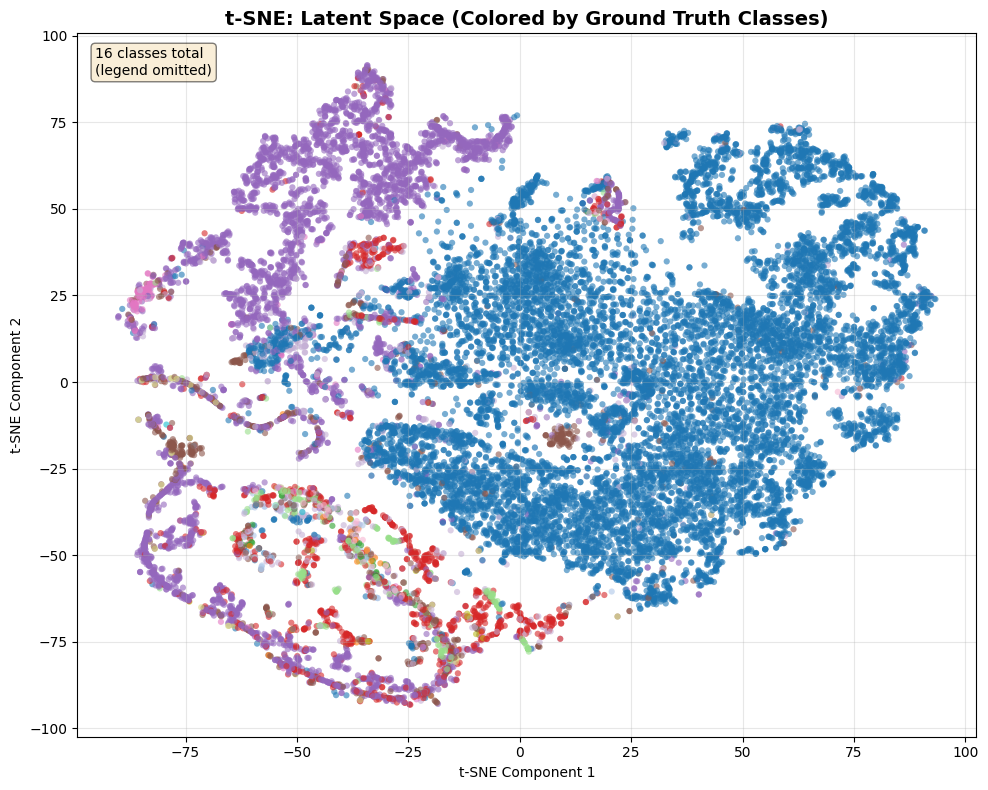


✓ Visualization complete. Latent dimensions: 128


In [24]:
# 5.2 Latent Space Visualization (t-SNE and UMAP)
from sklearn.manifold import TSNE
import matplotlib.cm as cm
import matplotlib.patches as mpatches

# Prepare normalized latent space for visualization
scaler_viz = StandardScaler()
latent_normalized_viz = scaler_viz.fit_transform(latent_flat)

# Create color map for all classes
unique_classes = df['class'].unique()
n_classes = len(unique_classes)
colors_map = cm.get_cmap('tab20', n_classes)
class_to_color = {cls: colors_map(i) for i, cls in enumerate(unique_classes)}
colors_by_class = [class_to_color[cls] for cls in df['class']]

print("Computing dimensionality reductions for visualization...")

# ============================================================================
# t-SNE Embedding
# ============================================================================
print("  - Computing t-SNE (this may take 1-2 minutes)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=0)
tsne_embedding = tsne.fit_transform(latent_normalized_viz)
print("  ✓ t-SNE complete")

# ============================================================================
# UMAP Embedding (if available)
# ============================================================================
try:
    import umap
    print("  - Computing UMAP...")
    umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    umap_embedding = umap_reducer.fit_transform(latent_normalized_viz)
    print("  ✓ UMAP complete")
    has_umap = True
except ImportError:
    print("  ⚠ UMAP not installed (pip install umap-learn). Skipping UMAP visualization.")
    has_umap = False

# ============================================================================
# Plotting
# ============================================================================
n_plots = 2 if has_umap else 1
fig, axes = plt.subplots(1, n_plots, figsize=(10*n_plots, 8))
if n_plots == 1:
    axes = [axes]

# Plot 1: t-SNE colored by ground truth
ax = axes[0]
scatter = ax.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], 
                     c=colors_by_class, s=20, alpha=0.6, edgecolors='none')
ax.set_title('t-SNE: Latent Space (Colored by Ground Truth Classes)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.grid(True, alpha=0.3)

# Create legend (limit to reasonable number of classes)
if n_classes <= 15:
    patches = [mpatches.Patch(color=class_to_color[cls], label=cls) 
               for cls in unique_classes]
    ax.legend(handles=patches, loc='best', ncol=2 if n_classes > 8 else 1, 
              fontsize=8, framealpha=0.9)
else:
    ax.text(0.02, 0.98, f'{n_classes} classes total\n(legend omitted)', 
            transform=ax.transAxes, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: UMAP colored by ground truth (if available)
if has_umap:
    ax = axes[1]
    scatter = ax.scatter(umap_embedding[:, 0], umap_embedding[:, 1], 
                         c=colors_by_class, s=20, alpha=0.6, edgecolors='none')
    ax.set_title('UMAP: Latent Space (Colored by Ground Truth Classes)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('UMAP Component 1')
    ax.set_ylabel('UMAP Component 2')
    ax.grid(True, alpha=0.3)
    
    if n_classes <= 15:
        patches = [mpatches.Patch(color=class_to_color[cls], label=cls) 
                   for cls in unique_classes]
        ax.legend(handles=patches, loc='best', ncol=2 if n_classes > 8 else 1, 
                  fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.show()

print(f"\n✓ Visualization complete. Latent dimensions: {latent_flat.shape[1]}")